# Record and change a trained robotics policy

Use the same tools as the [image-model notebook](18_resnet_experiment_toolbox.ipynb) to record internal activity, silence one unit, and check restoration. A robotics policy is a model that predicts actions from observations.

**This notebook reads saved measurements from the trained `pi05_libero` policy on an NVIDIA L4.** The input came from LIBERO, a simulated robot evaluation. Reading these results needs the [UMI notebook environment](../install/README.md), but no JAX installation, checkpoint download, or GPU.

In [1]:
from pathlib import Path
from IPython.display import Image, display
import numpy as np

# Read saved Brain-Score measurements without calling a model.
from brainscore.run_record import RunRecord

assets = Path('assets/openpi')
records = assets / 'records'


## 1. Choose a layer and unit

An OpenPI policy refines a predicted **action chunk**: several actions to use in succession. Each **denoising step** is one internal refinement, not a moment in the simulator.

Here we selected unit `0` of `action_out_proj` at denoising steps `0` and `1`. This layer produces an internal update used to refine the predicted actions. Silencing it does not mean setting the final robot command to zero.

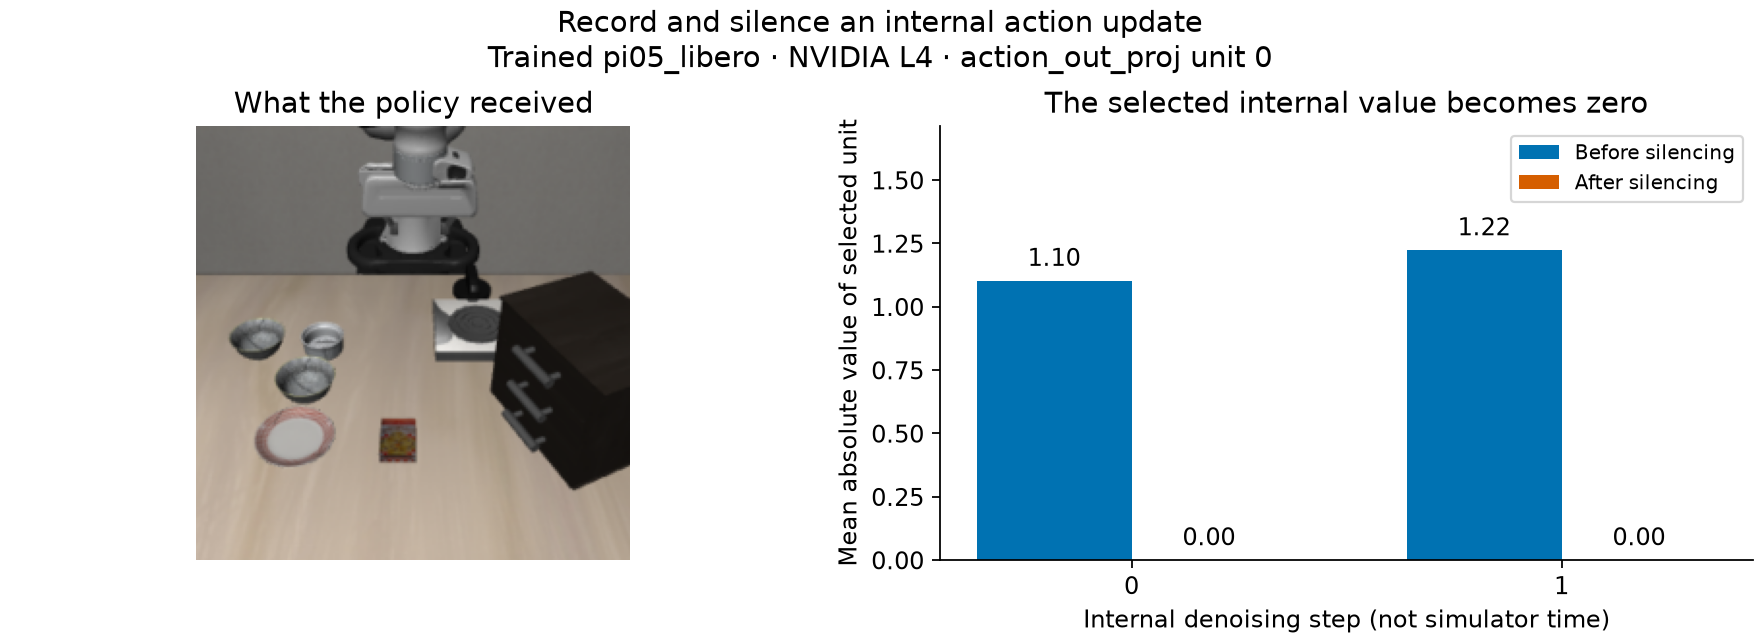

In [2]:
# Display a figure generated from the saved activity measurements.
display(Image(filename=str(assets / 'activity.png')))


The policy was asked to **pick up the black bowl between the plate and the ramekin and place it on the plate**. The image is one camera observation it received.

Each bar averages the selected internal unit across ten predicted action positions. Brain-Score recorded the value immediately before and after silencing it. The orange bars are zero.

## 2. Compare the predicted actions

The saved experiments compare four conditions: baseline (normal model), recording only, ablation (one unit silenced), and restored (tools removed). Each uses the same observation and starting random state. Removing the intervention restores the baseline prediction exactly; blue and green overlap.

The two panels show values in LIBERO's movement command. They are not joint angles, measured movements, or task-success scores.

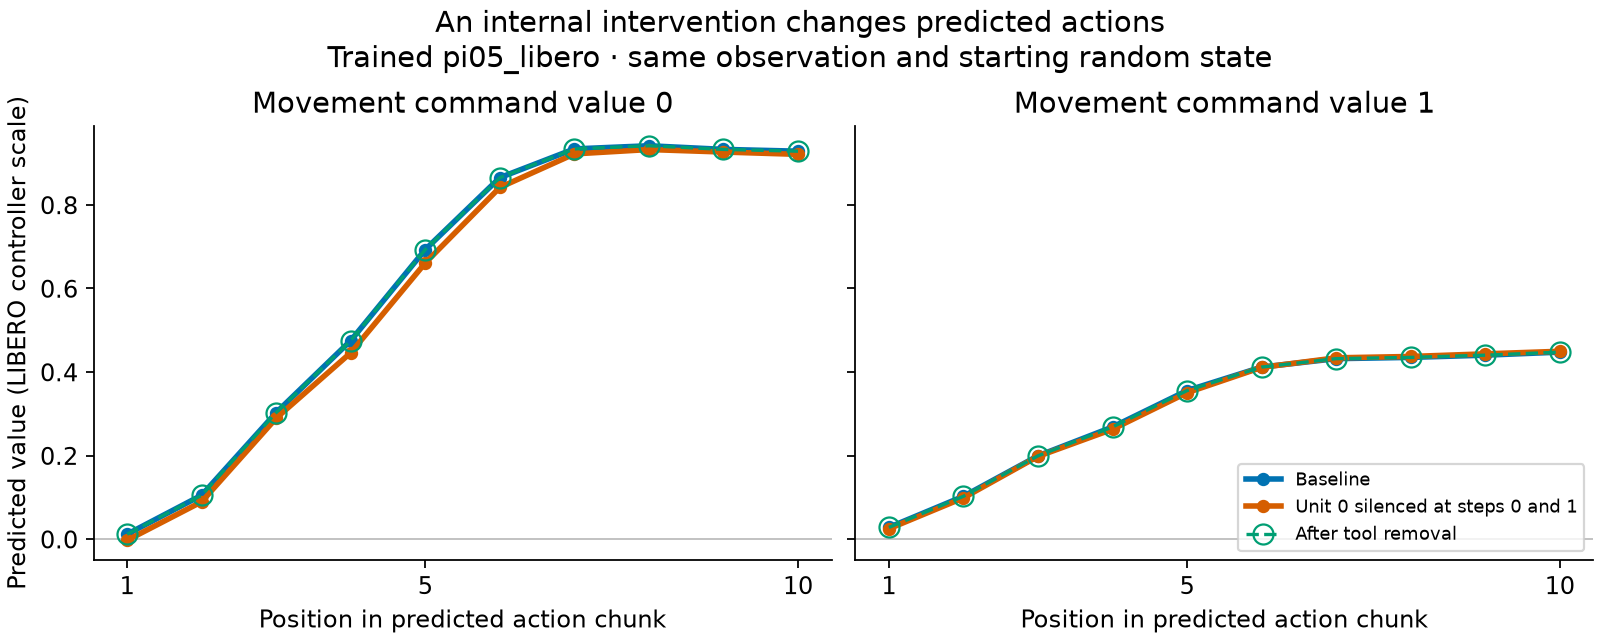

In [3]:
display(Image(filename=str(assets / 'actions.png')))

# Load the first action chunk returned in each saved experiment.
actions = {}
for condition in ['baseline', 'recording', 'ablation', 'restored']:
    events = RunRecord(records / condition).events()
    actions[condition] = next(
        event['payload']['actions']
        for event in events
        if event['kind'] == 'output'
    )

# Recording alone and tool removal must preserve the original prediction exactly.
np.testing.assert_array_equal(actions['baseline'], actions['recording'])
np.testing.assert_array_equal(actions['baseline'], actions['restored'])
assert not np.array_equal(actions['baseline'], actions['ablation'])


## 3. Inspect what the policy received and returned

A call identifier connects the input, internal measurements, and output. Opening a `RunRecord` reads saved data; it does not rerun inference.

In [4]:
# Read saved events and select the first call and its activity measurements.
events = list(RunRecord(records / 'ablation').events())
received = next(event for event in events if event['kind'] == 'input')
returned = next(event for event in events if event['kind'] == 'output')
request = received['payload']['args'][0]
activity = [
    event for event in events
    if event['kind'] == 'activity'
    and event['event_id'] == received['event_id']
]

# Show the small state/action arrays; camera arrays are available in request['observation/image'].
{
    'received state': request['observation/state'],
    'returned actions': returned['payload']['actions'],
    'linked internal measurements': len(activity),
    'same call': received['event_id'] == returned['event_id'],
}


{'received state': array([-2.11241627e-01, -1.10906019e-02,  1.17424952e+00,  3.14089540e+00,
        -2.84781983e-03, -8.77393103e-02,  3.87233651e-02, -3.87222021e-02]),
 'returned actions': array([[-2.73564333e-03,  2.47866044e-02,  5.28822112e-02,
         -1.63020153e-02,  5.10833295e-03,  4.84426506e-03,
         -9.99879682e-01],
        [ 8.94412294e-02,  9.87611572e-02,  1.21689944e-01,
         -3.19475030e-02,  7.56663010e-03,  4.81770666e-03,
         -1.00186668e+00],
        [ 2.89470362e-01,  1.98045235e-01,  1.80553023e-01,
         -3.51960985e-02,  2.15480378e-02,  8.36816257e-03,
         -1.00408139e+00],
        [ 4.46086274e-01,  2.62968780e-01,  1.76490957e-01,
         -2.03911023e-02,  2.21328995e-02,  9.90456850e-03,
         -1.00304662e+00],
        [ 6.60992279e-01,  3.50462411e-01,  1.64137603e-01,
         -9.65276024e-03,  1.24871098e-02,  1.83816460e-02,
         -1.00004529e+00],
        [ 8.41712702e-01,  4.11023872e-01,  1.52249630e-01,
         -7.7

## 4. Choose the tools and run (optional)

Keep the same `Experiment`, `RecordInputsOutputs`, `RecordActivity`, `Ablate`, and `Selection` used elsewhere in UMI. Two connections change:

- `CallableProtocol` runs an existing function and observes its model calls. Use it here for OpenPI's `infer()` method; `SessionProtocol` instead runs a subject's `interact(session)` method.
- `RemoteOpenPIInstrumentation` connects the tools to the policy inside the server, just as `TorchInstrumentation` connects them to a local PyTorch model.

Here the policy client fills the experiment's `subject` role. `infer()` is OpenPI's method name, not a requirement for all UMI subjects.

Start the [OpenPI tool server](../docs/policy_instrumentation.md#remote-policy) with `--steps 0 1`. Supply a completed raw LIBERO call record from the matching policy. This cell makes one inference call; the [evaluator bridge](../examples/libero/serve_tool_bridge.py) connects the same tools to a simulator run.


In [5]:
# Leave False to read the saved results without connecting to a server.
RUN_LIVE = False
source_record = Path('/path/to/completed/libero-call-record')

if RUN_LIVE:
    import tempfile
    from brainscore_core.events import Selection
    from brainscore.experiments import (
        Experiment,
        CallableProtocol,
        RecordInputsOutputs,
        RecordActivity,
        Ablate,
        OpenPIPolicyClient,
        RemoteOpenPIInstrumentation,
    )

    # Read one actual evaluator request for the trained policy.
    source = RunRecord(source_record)
    assert source.manifest['status'] == 'complete'
    request = next(
        event['payload']
        for event in source.events()
        if event['kind'] == 'input'
    )

    # The protocol supplies the subject and run context to this function.
    def evaluate(subject, context):
        return subject.infer(request)

    # Select one internal unit, using the same selector as other UMI models.
    target = Selection(layer='action_out_proj', indices=[0])
    output_folder = Path(tempfile.mkdtemp(prefix='umi-openpi-'))

    # Open the policy connection and close it when this block finishes.
    with OpenPIPolicyClient('ws://127.0.0.1:8001') as subject:
        result = Experiment(
            subject=subject,  # The model adapter to run.
            protocol=CallableProtocol(
                'inspect-policy',
                evaluate,
                methods=['infer'],  # Observe calls to this policy method.
            ),
            tools=[
                RecordInputsOutputs(),  # Save inputs, outputs, and tool measurements.
                # Measure the selected unit before silencing it.
                RecordActivity(
                    [target],
                    when='before',
                    name='before',
                ),
                Ablate([target]),  # Silence the selected internal value.
                # Measure the same unit after silencing it.
                RecordActivity(
                    [target],
                    when='after',
                    name='after',
                ),
            ],
            # Connect the tools to the policy inside the server.
            instrumentation=RemoteOpenPIInstrumentation(subject),
            output_dir=output_folder / 'experiment',  # Save in a new folder.
        ).run()  # Run, save measurements, and detach the tools.


## 5. Review the measured results

| Check | Measured result |
| --- | --- |
| Record selected units at each of three internal sites | Exact predictions on ten saved inputs per site |
| Record and remove tools through the remote server | Exact predictions on ten saved inputs |
| Run LIBERO Spatial with recording off/on | 10/10 successes in each; all 223 calls had identical inputs and actions |
| Silence unit 0 at denoising steps 0 and 1 | Internal value became zero and actions changed; still 10/10 successes |

Silencing a value can change actions without making these tasks fail. Ten trials are a smoke check, not full benchmark reproduction or evidence about physical robots. Paired simulator runs used fresh policy servers and shared GPU compiler settings; separate processes without these controls can differ numerically.

[Qualification details](../docs/qualification/2026-10-06-openpi-tools.md) · [Saved-data provenance](assets/openpi/README.md) · [Notebook guide](README.md) · [Shared vocabulary](../docs/conventions.md)